In [1]:
# @title 1.1 🔍 Check GPU
import torch

print("🔍 GPU Check:")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem_gb = props.total_memory / 1024**3
        print(f"   GPU {i}: {props.name} ({mem_gb:.1f} GB)")
else:
    print("❌ GPU not found! Enable GPU in Kaggle Settings.")

🔍 GPU Check:
   GPU 0: Tesla T4 (14.7 GB)
   GPU 1: Tesla T4 (14.7 GB)


In [2]:
# @title 0.0 🔇 Silence Warnings (Chạy cell này đầu tiên)
import os
import warnings
import logging

# 1. Tắt cảnh báo Tokenizers Parallelism (Fix lỗi "fork" & "deadlock")
# Đặt là "false" vì ta đã dùng dataloader_num_workers của PyTorch để đa luồng rồi
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 2. Tắt các cảnh báo Python thông thường (Fix lỗi "checkpoint", "None of inputs...")
# Chỉ hiện lỗi (ERROR), ẩn cảnh báo (WARNING)
warnings.filterwarnings("ignore")

# 3. Tắt log rác của Hugging Face Transformers
logging.getLogger("transformers").setLevel(logging.ERROR)

print("✅ Đã tắt các cảnh báo (Warnings suppressed). Log sẽ sạch hơn!")

✅ Đã tắt các cảnh báo (Warnings suppressed). Log sẽ sạch hơn!


In [3]:
# @title 1.2 📦 Clone Repository & Install Dependencies
import os
import sys

REPO_URL = "https://github.com/ngnam1104/TriMedAgent.git"
WORK_DIR = "/kaggle/working/TriMedAgent"

if not os.path.exists(WORK_DIR):
    print("📥 Cloning TriMedAgent...")
    !git clone {REPO_URL} {WORK_DIR}
else:
    print("✅ Repository exists.")

os.chdir(WORK_DIR)
sys.path.insert(0, WORK_DIR)

# Install dependencies (standard transformers + peft, NOT unsloth)
print("\n📦 Installing training dependencies...")
!pip install -q transformers>=4.36.0
!pip install -q peft>=0.7.0
!pip install -q accelerate>=0.25.0
!pip install -q bitsandbytes>=0.41.0
!pip install -q datasets wandb huggingface_hub
!pip install -q trl>=0.7.0

print("\n✅ Installation Complete!")
print("   Using: transformers + peft (standard training)")

📥 Cloning TriMedAgent...
Cloning into '/kaggle/working/TriMedAgent'...
remote: Enumerating objects: 651, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 651 (delta 37), reused 77 (delta 22), pack-reused 552 (from 1)
Receiving objects: 100% (651/651), 52.61 MiB | 22.20 MiB/s, done.
Resolving deltas: 100% (114/114), done.

📦 Installing training dependencies...

✅ Installation Complete!
   Using: transformers + peft (standard training)


In [4]:
# @title 1.3 🔑 Setup HuggingFace Token (Kaggle Version)
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

try:
    # Lấy token từ Kaggle Secrets (Menu Add-ons -> Secrets)
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
    login(token=HF_TOKEN)
    print("✅ Logged in to HuggingFace via Kaggle Secrets!")
except Exception as e:
    print(f"⚠️ Không tìm thấy 'HF_TOKEN' trong Secrets. Lỗi: {e}")
    print("   Hãy thêm token vào menu 'Add-ons' -> 'Secrets' ở thanh công cụ phía trên.")

    # Nhập thủ công nếu không set secret
    HF_TOKEN = input("Hoặc nhập HuggingFace Token trực tiếp tại đây: ")
    if HF_TOKEN:
        login(token=HF_TOKEN)
        print("✅ Logged in manually!")

✅ Logged in to HuggingFace via Kaggle Secrets!


---
## 2️⃣ 📊 Download & Preprocess Training Data

**Data Sources cho SFT:**
- **VQA-RAD**: Visual Question Answering in Radiology
- **SLAKE**: Structured Medical Knowledge VQA
- **VinDr-CXR**: Vietnamese X-ray with Detection Boxes

**Output Format (ReAct-style):**
```json
{
    "image": "path/to/img.jpg",
    "conversations": [
        {"role": "user", "content": "<image>\nQuestion"},
        {"role": "assistant", "content": "{\"thought\": \"...\", \"action\": \"...\", \"action_input\": {...}}"}
    ]
}
```

In [5]:
# @title 2.1 📥 Download VQA-RAD Dataset from HuggingFace
import os
import json
from pathlib import Path
from datasets import load_dataset
from tqdm import tqdm

# Cài đặt thư viện datasets nếu chưa có
try:
    import datasets
except ImportError:
    !pip install -q datasets
    from datasets import load_dataset

DATA_DIR = Path("data")
SFT_DIR = DATA_DIR / "sft_dataset"
RAW_DIR = DATA_DIR / "raw"
IMG_DIR = RAW_DIR / "images"

# Tạo thư mục
SFT_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("📥 DOWNLOADING VQA-RAD DATASET FROM HUGGINGFACE")
print("="*60)

try:
    # Tải dataset từ Hugging Face
    hf_dataset_name = "flaviagiammarino/vqa-rad"
    print(f"🚀 Loading {hf_dataset_name}...")
    dataset = load_dataset(hf_dataset_name)

    # Chuẩn bị list để lưu metadata
    all_data = []

    # Duyệt qua cả tập train và test
    splits = list(dataset.keys()) # thường là ['train', 'test']

    total_samples = sum(len(dataset[split]) for split in splits)
    print(f"📦 Total samples found: {total_samples}")
    print("💾 Saving images to disk...")

    global_idx = 0

    # Progress bar
    with tqdm(total=total_samples) as pbar:
        for split in splits:
            for item in dataset[split]:
                # Lấy các trường dữ liệu
                image_obj = item['image']
                question = item['question']
                answer = str(item['answer']) # Đảm bảo answer là string

                # Tạo tên file ảnh duy nhất
                image_filename = f"vqarad_{split}_{global_idx}.jpg"
                image_path = IMG_DIR / image_filename

                # Lưu file ảnh xuống ổ cứng (để model có thể đọc path)
                # Convert sang RGB để tránh lỗi nếu ảnh là RGBA/Grayscale
                if image_obj.mode != "RGB":
                    image_obj = image_obj.convert("RGB")
                image_obj.save(image_path)

                # Lưu thông tin vào list
                record = {
                    "image_path": str(image_path),
                    "question": question,
                    "answer": answer,
                    "split": split,
                    "origin": "huggingface"
                }
                all_data.append(record)

                global_idx += 1
                pbar.update(1)

    # Lưu file metadata tổng hợp (JSON)
    metadata_path = RAW_DIR / "vqa_rad_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(all_data, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Success! Processed {len(all_data)} items.")
    print(f"📁 Images saved to: {IMG_DIR}")
    print(f"📝 Metadata saved to: {metadata_path}")

    # Preview
    print("\n👀 Preview first record:")
    print(json.dumps(all_data[0], indent=2))

except Exception as e:
    print(f"\n❌ Error downloading/processing dataset: {e}")

📥 DOWNLOADING VQA-RAD DATASET FROM HUGGINGFACE
🚀 Loading flaviagiammarino/vqa-rad...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

📦 Total samples found: 2244
💾 Saving images to disk...


100%|██████████| 2244/2244 [00:11<00:00, 200.76it/s]


✅ Success! Processed 2244 items.
📁 Images saved to: data/raw/images
📝 Metadata saved to: data/raw/vqa_rad_metadata.json

👀 Preview first record:
{
  "image_path": "data/raw/images/vqarad_train_0.jpg",
  "question": "are regions of the brain infarcted?",
  "answer": "yes",
  "split": "train",
  "origin": "huggingface"
}


In [6]:
# @title 2.2 📥 Download SLAKE Dataset (Fix: Unzip imgs.zip)
import os
import json
import shutil
import zipfile
from pathlib import Path
from huggingface_hub import snapshot_download
from tqdm import tqdm

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
SLAKE_DIR = RAW_DIR / "SLAKE_HF"
IMG_DIR = RAW_DIR / "images"

# Tạo thư mục
SLAKE_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("📥 DOWNLOADING SLAKE RAW FILES (WITH UNZIP)")
print("="*60)

try:
    repo_id = "BoKelvin/SLAKE"
    print(f"🚀 Snapshot downloading from {repo_id}...")

    local_dir = snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        local_dir=SLAKE_DIR,
        resume_download=True
    )
    print(f"✅ Downloaded raw files to: {local_dir}")

    # --- SỬA LỖI: GIẢI NÉN imgs.zip ---
    zip_path = Path(local_dir) / "imgs.zip"
    source_imgs_dir = Path(local_dir) / "imgs"

    if zip_path.exists():
        print(f"📦 Found imgs.zip! Extracting...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_dir)
        print("✅ Extraction complete.")

    # Kiểm tra lại sau khi giải nén
    if not source_imgs_dir.exists():
        # Đôi khi zip giải nén ra folder tên khác, thử tìm folder con
        possible_dirs = [d for d in Path(local_dir).iterdir() if d.is_dir() and 'img' in d.name.lower()]
        if possible_dirs:
            source_imgs_dir = possible_dirs[0]
            print(f"⚠️ Found images in alternative folder: {source_imgs_dir}")
        else:
            raise FileNotFoundError("Still cannot find 'imgs' folder after unzip!")

    num_files = sum(1 for _ in source_imgs_dir.rglob('*') if _.is_file())
    print(f"🧐 Debug: Found {num_files} files in images folder.")

    # --- XỬ LÝ METADATA ---
    print("💾 Processing metadata and organizing images...")

    all_data = []
    json_files = ['train.json', 'validate.json', 'test.json']
    saved_images = set()

    for j_file in json_files:
        j_path = Path(local_dir) / j_file
        if j_path.exists():
            with open(j_path, 'r') as f:
                data = json.load(f)

            split_name = j_file.split('.')[0]

            for item in tqdm(data, desc=f"Processing {split_name}"):
                if item.get('q_lang') != 'en': continue

                raw_path = item['img_name'] # vd: xmlab1/source.jpg

                # Tìm file ảnh gốc
                src_image_path = source_imgs_dir / raw_path

                # Tạo tên file mới phẳng
                safe_filename = raw_path.replace('/', '_')
                dest_image_path = IMG_DIR / safe_filename

                if src_image_path.exists():
                    if safe_filename not in saved_images:
                        shutil.copy2(src_image_path, dest_image_path)
                        saved_images.add(safe_filename)

                    record = {
                        "image_path": str(dest_image_path),
                        "question": item['question'],
                        "answer": str(item['answer']),
                        "modality": item.get('modality', 'Unknown'),
                        "location": item.get('location', 'Unknown'),
                        "split": split_name,
                        "origin": "slake_hf"
                    }
                    all_data.append(record)

    # Lưu metadata
    metadata_path = RAW_DIR / "slake_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(all_data, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Success! Processed {len(all_data)} items.")
    print(f"📁 Images centralized at: {IMG_DIR}")
    print(f"📝 Metadata saved to: {metadata_path}")

except Exception as e:
    print(f"\n❌ Error: {e}")

📥 DOWNLOADING SLAKE RAW FILES (WITH UNZIP)
🚀 Snapshot downloading from BoKelvin/SLAKE...


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

imgs.zip:   0%|          | 0.00/212M [00:00<?, ?B/s]

KG.zip:   0%|          | 0.00/81.7k [00:00<?, ?B/s]

validation.json: 0.00B [00:00, ?B/s]

...

train.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

✅ Downloaded raw files to: /kaggle/working/TriMedAgent/data/raw/SLAKE_HF
📦 Found imgs.zip! Extracting...
✅ Extraction complete.
🧐 Debug: Found 2584 files in images folder.
💾 Processing metadata and organizing images...


Processing test: 100%|██████████| 2094/2094 [00:00<00:00, 51341.11it/s]


✅ Success! Processed 5980 items.
📁 Images centralized at: data/raw/images
📝 Metadata saved to: data/raw/slake_metadata.json


In [7]:
# @title 2.2b 📥 Download RAG Dataset (MedQuAD)
from datasets import load_dataset
import pandas as pd
from pathlib import Path

print("="*60)
print("📥 DOWNLOADING REAL MEDICAL QA (RAG DATA)")
print("="*60)

# Tải dataset MedQuAD từ HuggingFace
try:
    print("   ... Downloading keivalya/MedQuad-MedicalQnADataset")
    medquad = load_dataset("keivalya/MedQuad-MedicalQnADataset", split="train")
    print(f"✅ Downloaded {len(medquad)} QA pairs.")
except Exception as e:
    print(f"❌ Error downloading: {e}")
    medquad = []

# Lưu tạm ra biến global để Cell 2.3 dùng
# (Không cần lưu file vì cell 2.3 sẽ xử lý luôn)
print("✅ MedQuAD loaded into memory ready for preprocessing.")

📥 DOWNLOADING REAL MEDICAL QA (RAG DATA)
   ... Downloading keivalya/MedQuad-MedicalQnADataset


README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

✅ Downloaded 16407 QA pairs.
✅ MedQuAD loaded into memory ready for preprocessing.


In [8]:
# @title 2.3 🔄 Preprocess VQA & RAG → ReAct JSON (Enhanced Detection & Sampling)
import json
import random
from pathlib import Path
from tqdm import tqdm
from PIL import Image

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
SFT_DIR = DATA_DIR / "sft_dataset"
SFT_DIR.mkdir(parents=True, exist_ok=True)

# Tạo ảnh giả cho RAG
dummy_path = RAW_DIR / "dummy_rag.jpg"
if not dummy_path.exists():
    Image.new('RGB', (224, 224), color='black').save(dummy_path)
    
print("="*60)
print("🔄 PREPROCESSING: Optimized for Detection & Zoom")
print("="*60)

# ==========================================
# 1. 🧠 SMART LOGIC: PHÂN LOẠI VẬT THỂ
# ==========================================
def create_plan(question, q_type="vision"):
    q_lower = question.lower()
    
    if q_type == "rag":
        return {
            "thought": "This is a theoretical medical question requiring knowledge retrieval.",
            "tool": "Knowledge",
            "action": "Medical_RAG", 
            "action_input": {"query": question}
        }
    
    # --- DANH SÁCH TỪ KHÓA CHI TIẾT ---
    # Vật thể nhỏ/khó thấy -> Cần Zoom + MedSAM
    small_targets = [
        'nodule', 'lesion', 'fracture', 'mass', 'opacity', 'calcification', 
        'stone', 'micro', 'small', 'tiny', 'spot', 'foreign body', 'vessel'
    ]
    # Vật thể lớn/giải phẫu -> GroundingDINO
    large_targets = [
        'lung', 'heart', 'liver', 'kidney', 'brain', 'stomach', 'spine', 
        'rib', 'bone', 'organ', 'abdomen', 'chest', 'skull'
    ]
    # Từ khóa yêu cầu tìm vị trí
    detection_queries = ['where', 'locate', 'find', 'show', 'position', 'point to', 'presence of']

    # Kiểm tra nếu là câu hỏi định vị
    if any(k in q_lower for k in detection_queries):
        # Tìm target cụ thể trong câu hỏi
        target = "abnormality"
        for t in (small_targets + large_targets):
            if t in q_lower:
                target = t
                break
        
        # LOGIC: Vật nhỏ -> ZoomProcessor (Dino + MedSAM)
        if any(s in q_lower for s in small_targets):
            return {
                "thought": f"The target '{target}' is a small medical feature. I need to Ground it and then use MedSAM/Zoom for precise segmentation.",
                "tool": "Vision",
                "action": "ZoomProcessor",
                "action_input": {"target": target, "mode": "medsam_zoom"}
            }
        # LOGIC: Vật lớn -> GroundingDINO
        else:
            return {
                "thought": f"The target '{target}' is a major anatomical structure. I will use GroundingDINO to locate its bounding box.",
                "tool": "Vision",
                "action": "GroundingDINO",
                "action_input": {"target": target}
            }
            
    # Mặc định: Visual Answering
    return {
        "thought": "I need to perform a general visual analysis of this medical image to answer the user.",
        "tool": "Vision",
        "action": "Visual_Answering",
        "action_input": {"focus": "general_analysis"}
    }

# ==========================================
# 2. XỬ LÝ & LỌC DỮ LIỆU (SAMPLING)
# ==========================================

def process_vision_smart(json_path, origin_name, limit):
    if not json_path.exists(): return []
    with open(json_path, 'r') as f: data = json.load(f)
    
    detection_data = []
    general_data = []

    for item in data:
        if not item.get('image_path'): continue
        
        plan = create_plan(item['question'], q_type="vision")
        record = {
            "id": f"{origin_name}_{len(detection_data) + len(general_data)}",
            "image": item['image_path'],
            "conversations": [
                {"from": "human", "value": f"<image>\n{item['question']}"},
                {"from": "gpt", "value": json.dumps(plan)}
            ],
            "action": plan['action']
        }

        # Phân loại để ưu tiên
        if plan['action'] in ['GroundingDINO', 'ZoomProcessor']:
            detection_data.append(record)
        else:
            general_data.append(record)

    # --- ƯU TIÊN GIỮ DETECTION, SAU ĐÓ LẤY GENERAL CHO ĐỦ LIMIT ---
    num_general_needed = max(0, limit - len(detection_data))
    sampled_general = random.sample(general_data, min(len(general_data), num_general_needed))
    
    final_vision = detection_data + sampled_general
    print(f"📦 {origin_name}: Kept {len(detection_data)} Detection/Zoom, {len(sampled_general)} General. Total: {len(final_vision)}")
    return final_vision

# --- RUN PROCESSING ---

# 1. VQA-RAD (Limit 1000)
vqa_rad = process_vision_smart(RAW_DIR / "vqa_rad_metadata.json", "VQA-RAD", 1000)

# 2. SLAKE (Limit 3000)
slake = process_vision_smart(RAW_DIR / "slake_metadata.json", "SLAKE", 3000)

# 3. MedQuAD (Limit 2000)
def process_rag_limit(medquad_data, limit=2000):
    if not medquad_data: return []
    dataset = medquad_data.shuffle(seed=42).select(range(min(limit, len(medquad_data))))
    processed = []
    for idx, item in enumerate(dataset):
        plan = create_plan(item['Question'], q_type="rag")
        processed.append({
            "id": f"RAG_{idx}",
            "image": str(dummy_path),
            "conversations": [
                {"from": "human", "value": f"<image>\n{item['Question']}"},
                {"from": "gpt", "value": json.dumps(plan)}
            ],
            "action": "Medical_RAG"
        })
    print(f"📦 MedQuAD: Processed {len(processed)} samples.")
    return processed

rag_data = process_rag_limit(globals().get('medquad'), 2000)

# 4. GỘP VÀ CHIA TÁCH
all_data = vqa_rad + slake + rag_data
random.shuffle(all_data)

# Thống kê nhanh
stats = {}
for d in all_data:
    stats[d['action']] = stats.get(d['action'], 0) + 1

print("\n📊 FINAL ACTION DISTRIBUTION:")
for act, count in stats.items():
    print(f"   - {act:18}: {count} ({count/len(all_data)*100:.1f}%)")

# Lưu file
with open(SFT_DIR / "train.json", 'w') as f:
    json.dump(all_data, f, indent=2)
with open(SFT_DIR / "val.json", 'w') as f:
    json.dump(all_data[:200], f, indent=2)

print(f"\n✅ Dataset finalized at {SFT_DIR}/train.json")

🔄 PREPROCESSING: Optimized for Detection & Zoom
📦 VQA-RAD: Kept 300 Detection/Zoom, 700 General. Total: 1000
📦 SLAKE: Kept 854 Detection/Zoom, 2146 General. Total: 3000
📦 MedQuAD: Processed 2000 samples.

📊 FINAL ACTION DISTRIBUTION:
   - Medical_RAG       : 2000 (33.3%)
   - Visual_Answering  : 2846 (47.4%)
   - GroundingDINO     : 1031 (17.2%)
   - ZoomProcessor     : 123 (2.1%)

✅ Dataset finalized at data/sft_dataset/train.json


In [9]:
# @title 2.4 📊 Verify SFT Dataset Statistics
import json
from pathlib import Path
from collections import Counter

SFT_DIR = Path("data/sft_dataset")
train_file = SFT_DIR / "train.json"

print("="*60)
print("📊 VERIFYING FINAL DATASET STATISTICS")
print("="*60)

if train_file.exists():
    with open(train_file, 'r') as f:
        data = json.load(f)

    print(f"✅ Loaded final dataset: {len(data)} samples")

    # Đếm nguồn dữ liệu
    sources = [item['id'].split('_')[0] for item in data]
    source_counts = Counter(sources)

    print("\n📈 Data Distribution:")
    for source, count in source_counts.items():
        print(f"   - {source}: {count} samples")

    # Check SLAKE specifically
    slake_count = source_counts.get('SLAKE', 0)
    if slake_count > 0:
        print(f"\n✅ SLAKE data confirmed integrated! ({slake_count} samples)")
    else:
        print("\n⚠️ WARNING: No SLAKE data found in training set!")

else:
    print("❌ Error: train.json not found. Please run Step 2.3 again.")

📊 VERIFYING FINAL DATASET STATISTICS
✅ Loaded final dataset: 6000 samples

📈 Data Distribution:
   - RAG: 2000 samples
   - VQA-RAD: 1000 samples
   - SLAKE: 3000 samples

✅ SLAKE data confirmed integrated! (3000 samples)


In [10]:
# @title 2.5 📦 Split & Save Final SFT Dataset
import json
import random
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

print("="*60)
print("📦 FINALIZING SFT DATASET SPLIT")
print("="*60)

SFT_DIR = Path("data/sft_dataset")
train_output = SFT_DIR / "train.json"
val_output = SFT_DIR / "val.json"

# 1. Load dữ liệu tổng hợp từ bước 2.3
# (Lúc này file train.json chứa cả VQA-RAD và SLAKE)
input_file = SFT_DIR / "train.json"

if not input_file.exists():
    print("❌ Error: train.json missing. Run Step 2.3 first!")
else:
    with open(input_file, 'r', encoding='utf-8') as f:
        all_data = json.load(f)

    print(f"📦 Total samples loaded: {len(all_data)}")

    # 2. Split Train/Val (90/10)
    # Dùng seed cố định để tái lập kết quả
    train_data, val_data = train_test_split(all_data, test_size=0.1, random_state=42, shuffle=True)

    # 3. Save files
    print("💾 Saving split datasets...")
    with open(train_output, 'w', encoding='utf-8') as f:
        json.dump(train_data, f, indent=2, ensure_ascii=False)

    with open(val_output, 'w', encoding='utf-8') as f:
        json.dump(val_data, f, indent=2, ensure_ascii=False)

    # 4. In thống kê
    print(f"\n" + "="*60)
    print("📊 DATASET SUMMARY")
    print("="*60)
    print(f"📄 Train set: {len(train_data)} samples -> Saved to {train_output}")
    print(f"📄 Val set:   {len(val_data)} samples -> Saved to {val_output}")

    # Thống kê Action Distribution (Quan trọng để biết model học gì)
    actions = []
    for item in train_data:
        try:
            # Lấy câu trả lời của GPT (Assistant)
            gpt_response = item['conversations'][1]['value']
            plan = json.loads(gpt_response)
            actions.append(plan.get('action', 'unknown'))
        except:
            actions.append('parse_error')

    print(f"\n📊 Action Distribution (Train Set):")
    action_counts = Counter(actions)
    for action, count in action_counts.most_common():
        pct = (count / len(train_data)) * 100
        print(f"   - {action:<15} : {count:5d} ({pct:.1f}%)")

    print("\n✅ Ready for Training!")

📦 FINALIZING SFT DATASET SPLIT
📦 Total samples loaded: 6000
💾 Saving split datasets...

📊 DATASET SUMMARY
📄 Train set: 5400 samples -> Saved to data/sft_dataset/train.json
📄 Val set:   600 samples -> Saved to data/sft_dataset/val.json

📊 Action Distribution (Train Set):
   - Visual_Answering :  2547 (47.2%)
   - Medical_RAG     :  1808 (33.5%)
   - GroundingDINO   :   931 (17.2%)
   - ZoomProcessor   :   114 (2.1%)

✅ Ready for Training!


📂 Đã load 5400 mẫu dữ liệu tổng hợp.

==================== 1. KIỂM TRA VISION (VQA-RAD) ====================

------------------------------------------------------------
🏷️  Source Type: VQA-RAD | ID: VQA-RAD_16
🖼️  Image Path: data/raw/images/vqarad_train_16.jpg
💬 Conversation:
   [HUMAN]: [IMAGE TOKEN]
is the gyral enhancement?
   [GPT]: {"thought": "I need to perform a general visual analysis of this medical image to answer the user.", "tool": "Vision", "action": "Visual_Answering", "action_input": {"focus": "general_analysis"}}


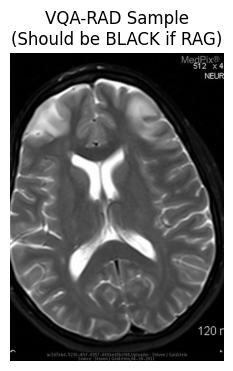


==================== 2. KIỂM TRA VISION (SLAKE) ====================

------------------------------------------------------------
🏷️  Source Type: SLAKE | ID: SLAKE_5471
🖼️  Image Path: data/raw/images/xmlab375_source.jpg
💬 Conversation:
   [HUMAN]: [IMAGE TOKEN]
What is the effect of the center organ in this picture?
   [GPT]: {"thought": "I need to perform a general visual analysis of this medical image to answer the user.", "tool": "Vision", "action": "Visual_Answering", "action_input": {"focus": "general_analysis"}}


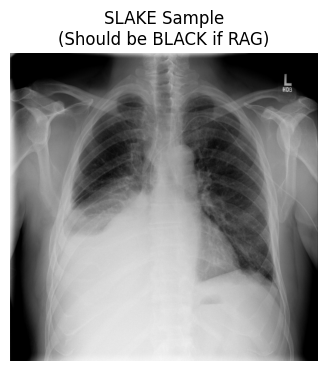


==================== 3. KIỂM TRA KNOWLEDGE (RAG) ====================

------------------------------------------------------------
🏷️  Source Type: RAG | ID: RAG_934
🖼️  Image Path: data/raw/dummy_rag.jpg
💬 Conversation:
   [HUMAN]: [IMAGE TOKEN]
Is hand-foot-genital syndrome inherited ?
   [GPT]: {"thought": "This is a theoretical medical question requiring knowledge retrieval.", "tool": "Knowledge", "action": "Medical_RAG", "action_input": {"query": "Is hand-foot-genital syndrome inherited ?"}}


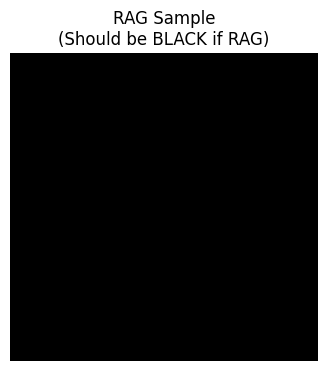

In [11]:
# @title 🔍 2.6 Visualize & Verify All Data Types (VQA, SLAKE, RAG)
import json
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Load file JSON dataset
data_path = Path("data/sft_dataset/train.json")

if not data_path.exists():
    print("⚠️ Chưa tìm thấy file train.json. Hãy chạy bước 2.3 trước!")
else:
    with open(data_path, 'r', encoding='utf-8') as f:
        dataset = json.load(f)

    print(f"📂 Đã load {len(dataset)} mẫu dữ liệu tổng hợp.")

    # 2. Hàm hiển thị mẫu
    def show_sample(source_prefix):
        # Lọc mẫu theo ID prefix (VQA-RAD_, SLAKE_, RAG_)
        samples = [item for item in dataset if item['id'].startswith(source_prefix)]

        if not samples:
            print(f"❌ Không tìm thấy mẫu nào có ID bắt đầu bằng: {source_prefix}")
            return

        # Lấy ngẫu nhiên
        item = random.choice(samples)
        img_path = item['image']
        convs = item['conversations']

        print("\n" + "-" * 60)
        print(f"🏷️  Source Type: {source_prefix} | ID: {item['id']}")
        print(f"🖼️  Image Path: {img_path}")
        
        # In hội thoại
        print("💬 Conversation:")
        for turn in convs:
            role = turn['from'].upper()
            # Thay thế token ảnh để dễ đọc
            content = turn['value'].replace("<image>", "[IMAGE TOKEN]")
            print(f"   [{role}]: {content}")

        # Hiển thị ảnh
        try:
            # Nếu là RAG (ảnh đen) hoặc ảnh thật
            img = Image.open(img_path)
            
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{source_prefix} Sample\n(Should be BLACK if RAG)")
            plt.show()
        except Exception as e:
            print(f"⚠️ Lỗi đọc ảnh: {e}")

    # 3. Chạy kiểm tra 3 loại
    print("\n" + "="*20 + " 1. KIỂM TRA VISION (VQA-RAD) " + "="*20)
    show_sample("VQA-RAD")

    print("\n" + "="*20 + " 2. KIỂM TRA VISION (SLAKE) " + "="*20)
    show_sample("SLAKE")
    
    print("\n" + "="*20 + " 3. KIỂM TRA KNOWLEDGE (RAG) " + "="*20)
    show_sample("RAG") # Đây là prefix chúng ta đặt ở bước 2.3

---
## 3️⃣ 🚀 Training Configuration

In [12]:
# @title 3.1 ⚙️ Training Config (Unified & Optimized for T4)
from dataclasses import dataclass
from typing import List

@dataclass
class SFTTrainingConfig:
    # Model
    base_model: str = "chaoyinshe/llava-med-v1.5-mistral-7b-hf"

    # LoRA (Tối ưu nhẹ cho tốc độ)
    lora_r: int = 32              # Giảm r xuống 32 (đủ cho SFT)
    lora_alpha: int = 64
    lora_dropout: float = 0.05
    # Chỉ train module quan trọng để giảm VRAM & Tăng tốc (Khoảng 2x nhanh hơn train all)
    target_modules: List[str] = None 

    # Training (Safe Mode cho 2xT4)
    num_epochs: int = 2
    batch_size: int = 8          # Batch size trên mỗi GPU
    gradient_accumulation_steps: int = 2 # Tích lũy để tương đương Batch 16
    learning_rate: float = 2e-5
    warmup_ratio: float = 0.03
    max_seq_length: int = 1024

    # Hardware settings (T4 specific)
    load_in_4bit: bool = True
    bf16: bool = False            # ❌ T4 không hỗ trợ tốt bfloat16 -> Tắt
    fp16: bool = True             # ✅ T4 bắt buộc dùng float16

    # Output
    output_dir: str = "checkpoints/sft_adapter"
    hub_model_id: str = "nhn309261/trimedagent-sft"

    def __post_init__(self):
        if self.target_modules is None:
            # Chỉ focus vào cơ chế Attention -> Nhẹ hơn nhiều so với "all-linear"
            self.target_modules = ["q_proj", "v_proj"]

config = SFTTrainingConfig()
print("✅ Config ready!")
print(f"   Base: {config.base_model}")
print(f"   Targets: {config.target_modules}")
print(f"   Batch: {config.batch_size} x {config.gradient_accumulation_steps} (Effective: {config.batch_size * config.gradient_accumulation_steps})")

✅ Config ready!
   Base: chaoyinshe/llava-med-v1.5-mistral-7b-hf
   Targets: ['q_proj', 'v_proj']
   Batch: 8 x 2 (Effective: 16)


In [13]:
# @title 3.2 📚 Load Model & Processor (Strategy: Kaggle 2xT4 Split)
from transformers import AutoTokenizer, AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
import torch
import os

# --- 1. Cấu hình Chiến lược 2 GPU (Kaggle T4 x2) ---
# T4 có 16GB VRAM.
# Model 7B 4-bit ~ 6GB.
# Để tận dụng 2 GPU (chia tải), ta giới hạn GPU 0 chỉ dùng 1 phần, ép các lớp sau sang GPU 1.
# Điều này giúp bạn có nhiều VRAM trống trên GPU 0 để chứa "Data" (Batch ảnh + Activations).

max_memory_mapping = {
    0: "7GB", # GPU 0 giữ 10GB (Model part 1 + Batch data)
    1: "7GB"  # GPU 1 giữ 15GB (Model part 2)
}

print(f"🚀 Loading {config.base_model} with 2xT4 Strategy...")

# 2. Config Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=config.load_in_4bit,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, # T4 dùng float16 tốt hơn bfloat16
    bnb_4bit_use_double_quant=True
)

# 3. Load Processor
processor = AutoProcessor.from_pretrained(config.base_model, trust_remote_code=True)
tokenizer = processor.tokenizer
tokenizer.padding_side = "right"
tokenizer.pad_token = tokenizer.unk_token

# 4. Load Model (Với Device Map thông minh)
model = LlavaForConditionalGeneration.from_pretrained(
    config.base_model,
    quantization_config=bnb_config,
    device_map="auto", # Tự động chia layer
    max_memory=max_memory_mapping, # Ép chia sang GPU 1
    trust_remote_code=True,
    torch_dtype=torch.float16
)

# 5. Prepare LoRA
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora_config = LoraConfig(
    r=config.lora_r,
    lora_alpha=config.lora_alpha,
    target_modules=config.target_modules,
    lora_dropout=config.lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    modules_to_save=["embed_tokens", "lm_head"]
)

model = get_peft_model(model, lora_config)

# In ra xem model nằm ở đâu
print("\n✅ Model Loaded!")
print(f"   GPU Memory Usage:")
for i in range(torch.cuda.device_count()):
    mem = torch.cuda.memory_allocated(i) / 1024**3
    print(f"   - GPU {i}: {mem:.2f} GB used")

2026-01-10 15:43:02.386501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768059782.588609      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768059782.648369      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768059783.100201      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768059783.100232      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768059783.100234      55 computation_placer.cc:177] computation placer alr

🚀 Loading chaoyinshe/llava-med-v1.5-mistral-7b-hf with 2xT4 Strategy...


processor_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]


✅ Model Loaded!
   GPU Memory Usage:
   - GPU 0: 2.54 GB used
   - GPU 1: 3.00 GB used


In [14]:
# @title 3.3 📊 Prepare Dataset (Perfect Logic for Vision + RAG)
from torch.utils.data import Dataset
import json
from PIL import Image
import torch
import os

# --- 1. SYSTEM PROMPT (Phải khớp 100% với format dữ liệu ở Cell 2.3) ---
SYSTEM_PROMPT = """You are TriMed-Agent, a medical AI assistant.
Analyze the input and respond with a structured JSON plan.
Format:
{
    "thought": "reasoning about the request",
    "tool": "Vision" or "Knowledge",
    "action": "tool name (GroundingDINO, ZoomProcessor, Medical_RAG, or Visual_Answering)",
    "action_input": {"param": "value"}
}"""
# -----------------------------------------------------------------------

class SFTDataset(Dataset):
    def __init__(self, data_path, processor, max_length=2048):
        self.processor = processor
        self.tokenizer = processor.tokenizer
        self.max_length = max_length
        self.data = []

        # Load JSON
        if os.path.exists(data_path):
            try:
                with open(data_path, 'r', encoding='utf-8') as f:
                    self.data = json.load(f)
                print(f"✅ Loaded {len(self.data)} examples from {data_path}")
            except Exception as e:
                print(f"❌ Error loading JSON: {e}")
                self.data = []
        else:
            print(f"⚠️ File not found: {data_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # --- YẾU TỐ 1: XỬ LÝ ẢNH (Vision vs RAG) ---
        # Logic: Thử mở ảnh thật. Nếu lỗi (hoặc không có path) -> Tạo ảnh đen ngay lập tức.
        image_path = item.get('image', '')
        try:
            if image_path and os.path.exists(image_path):
                image = Image.open(image_path).convert("RGB")
            else:
                raise FileNotFoundError("Image path invalid")
        except:
            # Fallback: Tạo ảnh đen (cho RAG data hoặc ảnh lỗi)
            image = Image.new('RGB', (224, 224), color='black')

        # --- YẾU TỐ 2: XÂY DỰNG PROMPT ---
        conversations = item.get('conversations', [])
        user_input = ""
        gpt_response = ""
        
        # Parse hội thoại
        for turn in conversations:
            role = turn.get('from') or turn.get('role')
            content = turn.get('value') or turn.get('content')
            if role in ['human', 'user']:
                # Xóa token <image> nếu có (vì ta sẽ tự thêm vào đúng chỗ)
                user_input = content.replace("<image>", "").strip()
            elif role in ['gpt', 'assistant']:
                gpt_response = content

        # Ghép chuỗi theo chuẩn LLaVA 1.5
        # Cấu trúc: USER: <image>\n{System}\n{Question}\nASSISTANT: {Answer}
        full_prompt = f"USER: <image>\n{SYSTEM_PROMPT}\n{user_input}\nASSISTANT: {gpt_response}"

        # --- YẾU TỐ 3: TOKENIZATION & MASKING ---
        # Processor tự động xử lý cả ảnh và chữ
        inputs = self.processor(
            text=full_prompt,
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length
        )

        input_ids = inputs['input_ids'][0]
        labels = input_ids.clone()

        # 3a. Mask Padding Tokens (Những chỗ là số 0 hoặc pad_token_id)
        if self.tokenizer.pad_token_id is not None:
            labels[labels == self.tokenizer.pad_token_id] = -100

        # 3b. Mask User Prompt (Chỉ tính Loss cho phần Assistant nói)
        # Tìm vị trí token "ASSISTANT:" cuối cùng
        assistant_token_id = self.tokenizer.encode("ASSISTANT:", add_special_tokens=False)[-1]
        
        try:
            # Tìm vị trí bắt đầu câu trả lời
            # (nonzero trả về danh sách các vị trí khớp, ta lấy cái cuối cùng)
            start_idx = (input_ids == assistant_token_id).nonzero(as_tuple=True)[0][-1].item()
            
            # Gán -100 từ đầu câu đến hết chữ "ASSISTANT:"
            # (+2 là để trừ hao cho khoảng trắng hoặc dấu :)
            labels[:start_idx + 2] = -100
        except:
            # Nếu không tìm thấy (hiếm gặp), mask toàn bộ để tránh học sai
            labels[:] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': inputs['attention_mask'][0],
            'pixel_values': inputs['pixel_values'][0],
            'labels': labels
        }

# Re-init datasets ngay sau khi chạy class
DEMO_MODE = True 

if 'processor' in globals() and 'config' in globals():
    print(f"🔄 Reloading Datasets (Demo Mode: {DEMO_MODE})...")
    
    # Khởi tạo dataset đầy đủ trước
    train_dataset = SFTDataset("data/sft_dataset/train.json", processor, config.max_seq_length)
    val_dataset = SFTDataset("data/sft_dataset/val.json", processor, config.max_seq_length)
    
    # 2. Áp dụng giới hạn nếu đang ở Demo Mode
    if DEMO_MODE:
        train_dataset.data = train_dataset.data[:20] # Chỉ lấy 20 mẫu đầu tiên
        val_dataset.data = val_dataset.data[:10]    # Chỉ lấy 10 mẫu đầu tiên
        print(f"⚠️ DEMO MODE ACTIVE: Limited to {len(train_dataset)} Train & {len(val_dataset)} Val samples.")
    else:
        print(f"🚀 FULL MODE ACTIVE: Loaded {len(train_dataset)} Train & {len(val_dataset)} Val samples.")
        
    print("✅ Datasets Ready!")

🔄 Reloading Datasets (Demo Mode: True)...
✅ Loaded 5400 examples from data/sft_dataset/train.json
✅ Loaded 600 examples from data/sft_dataset/val.json
⚠️ DEMO MODE ACTIVE: Limited to 20 Train & 10 Val samples.
✅ Datasets Ready!


In [15]:
# @title 📊 Analyze Token Lengths
import numpy as np

def analyze_lengths():
    lengths = []
    print("⏳ Analyzing token lengths...")
    
    for item in train_dataset.data:
        user_input = ""
        gpt_response = ""
        for turn in item['conversations']:
            if turn['from'] in ['human', 'user']:
                user_input = turn['value'].replace("<image>", "").strip()
            elif turn['from'] in ['gpt', 'assistant']:
                gpt_response = turn['value']

        # Giả lập prompt hoàn chỉnh như lúc train
        full_text = f"USER: <image>\n{SYSTEM_PROMPT}\n{user_input}\nASSISTANT: {gpt_response}"
        
        # Tokenize và đếm số lượng
        tokens = processor.tokenizer.encode(full_text)
        lengths.append(len(tokens))

    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_len = max(lengths)
    
    print(f"\n📊 THỐNG KÊ ĐỘ DÀI TOKEN:")
    print(f"   - Trung bình: {np.mean(lengths):.1f} tokens")
    print(f"   - Max: {max_len} tokens")
    print(f"   - 95th Percentile: {p95} tokens (95% dữ liệu ngắn hơn mức này)")
    print(f"   - 99th Percentile: {p99} tokens (99% dữ liệu ngắn hơn mức này)")
    
    return p99

# Chạy phân tích
optimal_len = analyze_lengths()

⏳ Analyzing token lengths...

📊 THỐNG KÊ ĐỘ DÀI TOKEN:
   - Trung bình: 187.6 tokens
   - Max: 219 tokens
   - 95th Percentile: 205 tokens (95% dữ liệu ngắn hơn mức này)
   - 99th Percentile: 216 tokens (99% dữ liệu ngắn hơn mức này)


---
## 4️⃣ 🔥 Start Training

In [16]:
# @title 4.1 🚀 Run Training (Linked to Config)
import torch
import gc
from transformers import Trainer, TrainingArguments

# --- Dọn dẹp bộ nhớ trước khi train ---
if 'trainer' in globals(): del trainer
gc.collect()
torch.cuda.empty_cache()

# --- 1. Custom Data Collator (Giữ nguyên) ---
class LLaVADataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, instances):
        input_ids = []
        attention_mask = []
        pixel_values = []
        labels = []

        for instance in instances:
            input_ids.append(instance['input_ids'])
            attention_mask.append(instance['attention_mask'])
            pixel_values.append(instance['pixel_values'])
            labels.append(instance['labels'])

        return {
            'input_ids': torch.stack(input_ids),
            'attention_mask': torch.stack(attention_mask),
            'pixel_values': torch.stack(pixel_values),
            'labels': torch.stack(labels)
        }

# --- 2. Training Arguments (Sử dụng biến config) ---
training_args = TrainingArguments(
    output_dir=config.output_dir,
    num_train_epochs=config.num_epochs,
    
    # === Tham số lấy từ Config 3.1 ===
    per_device_train_batch_size=config.batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    learning_rate=config.learning_rate,
    warmup_ratio=config.warmup_ratio,
    fp16=config.fp16,  # True cho T4
    bf16=config.bf16,  # False cho T4
    
    # === Cấu hình cố định cho hệ thống ===
    dataloader_num_workers=4,           # Tận dụng 4 vCPU Kaggle
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    group_by_length=True,
    logging_steps=1 if DEMO_MODE else 2,
    save_strategy="epoch",
    save_total_limit=1,
    report_to="none",
    remove_unused_columns=False,
    optim="paged_adamw_8bit"
)

# --- 3. Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=LLaVADataCollator(tokenizer),
)

# --- 4. Start Training ---
print(f"🚀 Starting Training with Optimized Config...")
print(f"   ► Effective Batch Size: {config.batch_size * config.gradient_accumulation_steps}")
print(f"   ► Target Modules: {config.target_modules}")

trainer.train()
trainer.save_model(config.output_dir)
print("✅ Training Complete!")

🚀 Starting Training with Optimized Config...
   ► Effective Batch Size: 16
   ► Target Modules: ['q_proj', 'v_proj']


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
1,1.328500
2,1.582400
3,1.407500
4,1.270300


✅ Training Complete!


🧪 TESTING 3 SPECIFIC SAMPLES (ONE FROM EACH DATASET)

############################################################
📌 TEST CASE: VQA-RAD (Vision)
############################################################
🆔 ID: VQA-RAD_1241
❓ Question: does this image show heart failure?
------------------------------
🤖 MODEL PREDICTION:
The image is a chest X-ray, and it is not possible to determine if the patient has heart failure. However, a chest X-ray can provide information about the lungs, heart, and other structures within the chest cavity. It is important to consider the patient's clinical history and symptoms, as well as consult a healthcare professional for a thorough evaluation and proper diagnosis.
------------------------------
✅ GROUND TRUTH (Target):
{"thought": "The target 'heart' is a major anatomical structure. I will use GroundingDINO to locate its bounding box.", "tool": "Vision", "action": "GroundingDINO", "action_input": {"target": "heart"}}


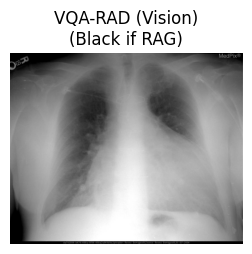


############################################################
📌 TEST CASE: SLAKE (Vision)
############################################################
🆔 ID: SLAKE_4850
❓ Question: Does the picture contain liver?
------------------------------
🤖 MODEL PREDICTION:
Yes, the picture contains liver tissue.
------------------------------
✅ GROUND TRUTH (Target):
{"thought": "I need to perform a general visual analysis of this medical image to answer the user.", "tool": "Vision", "action": "Visual_Answering", "action_input": {"focus": "general_analysis"}}


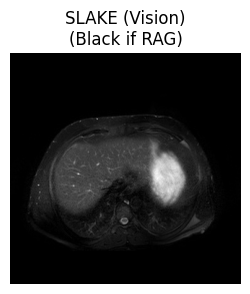


############################################################
📌 TEST CASE: MedQuAD (RAG)
############################################################
🆔 ID: RAG_1249
❓ Question: What are the symptoms of Gastroschisis ?
------------------------------
🤖 MODEL PREDICTION:
The symptoms of Gastroschisis can vary depending on the severity and location of the condition. Some common symptoms may include abdominal pain, nausea, vomiting, and a visible abdominal mass. However, it is important to note that the presence of these symptoms does not necessarily confirm the diagnosis of Gastroschisis. A healthcare professional would need to evaluate the patient's medical history, symptoms, and additional diagnostic tests to make an accurate diagnosis.
------------------------------
✅ GROUND TRUTH (Target):
{"thought": "This is a theoretical medical question requiring knowledge retrieval.", "tool": "Knowledge", "action": "Medical_RAG", "action_input": {"query": "What are the symptoms of Gastroschisis ?"

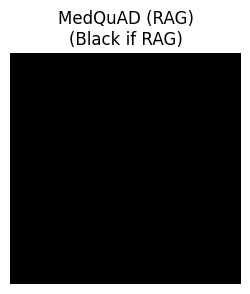

In [17]:
# @title 4.1.1 🧪 Evaluate 3 Specific Samples (VQA, SLAKE, RAG)
import random
import json
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

print("="*60)
print("🧪 TESTING 3 SPECIFIC SAMPLES (ONE FROM EACH DATASET)")
print("="*60)

# 1. Chuyển model sang chế độ eval (quan trọng)
model.eval()

# 2. System Prompt (Phải khớp 100% với lúc train)
SYSTEM_PROMPT = """You are TriMed-Agent, a medical AI assistant.
Analyze the input and respond with a structured JSON plan.
Format:
{
    "thought": "reasoning about the request",
    "tool": "Vision" or "Knowledge",
    "action": "tool name (GroundingDINO, ZoomProcessor, Medical_RAG, or Visual_Answering)",
    "action_input": {"param": "value"}
}"""

# 3. Hàm dự đoán
def predict(image_path, question):
    # Xử lý ảnh (Thật vs Giả)
    try:
        # Nếu path rỗng hoặc chứa từ khóa dummy/rag -> Tạo ảnh đen
        if not image_path or "dummy" in str(image_path) or "RAG" in str(image_path):
            image = Image.new('RGB', (224, 224), color='black')
        else:
            image = Image.open(image_path).convert("RGB")
    except:
        image = Image.new('RGB', (224, 224), color='black')

    # Tạo Prompt
    prompt = f"USER: <image>\n{SYSTEM_PROMPT}\n{question}\nASSISTANT:"

    # Tokenize
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    for key, value in inputs.items():
        inputs[key] = value.to(model.device)

    # Generate
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=True, # Dùng sampling để xem độ đa dạng, hoặc False để test độ ổn định
            temperature=0.2,
            top_p=0.9,
            use_cache=True
        )

    # Decode
    response = processor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
    if "ASSISTANT:" in response:
        response = response.split("ASSISTANT:")[-1].strip()
    return image, response

# 4. Logic chọn 3 mẫu đại diện từ tập Validation
# (Nếu Val không đủ, ta lấy tạm từ Train để test demo)
target_datasets = {
    "VQA-RAD (Vision)": "VQA-RAD",
    "SLAKE (Vision)": "SLAKE",
    "MedQuAD (RAG)": "RAG"
}

found_samples = {}

# Tìm trong val_dataset trước
source_data = val_dataset.data if len(val_dataset) > 0 else train_dataset.data

for name, prefix in target_datasets.items():
    # Lọc tất cả các items có ID bắt đầu bằng prefix
    candidates = [item for item in source_data if str(item['id']).startswith(prefix)]
    
    if candidates:
        found_samples[name] = random.choice(candidates)
    else:
        print(f"⚠️ Warning: Could not find any sample for {name}")

# 5. Chạy Test
for dataset_name, item in found_samples.items():
    print("\n" + "#"*60)
    print(f"📌 TEST CASE: {dataset_name}")
    print("#"*60)
    
    # Lấy thông tin
    img_path = item.get('image', '')
    question = ""
    # Lấy câu hỏi từ hội thoại
    for turn in item['conversations']:
        if turn['from'] in ['user', 'human']:
            question = turn['value'].replace("<image>", "").strip()
            break
            
    # Lấy Ground Truth (Kế hoạch mẫu)
    ground_truth = item['conversations'][1]['value']

    print(f"🆔 ID: {item['id']}")
    print(f"❓ Question: {question}")
    
    # Chạy dự đoán
    try:
        image, prediction = predict(img_path, question)
        
        print("-" * 30)
        print(f"🤖 MODEL PREDICTION:\n{prediction}")
        print("-" * 30)
        print(f"✅ GROUND TRUTH (Target):\n{ground_truth}")
        
        # Hiển thị ảnh
        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"{dataset_name}\n(Black if RAG)")
        plt.show()
        
    except Exception as e:
        print(f"❌ Error: {e}")

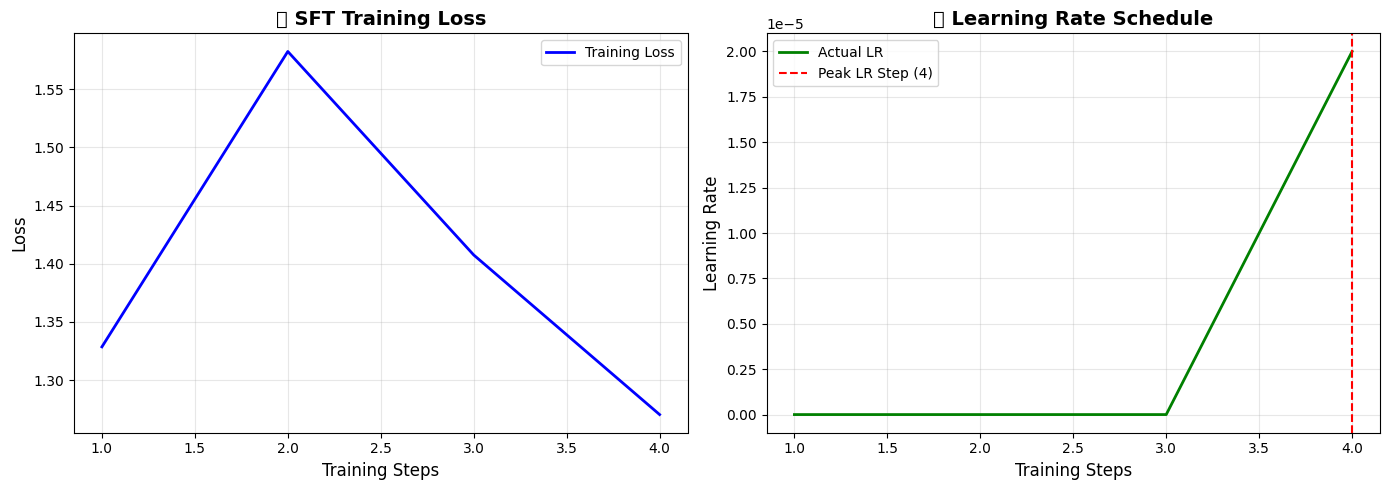

✅ Training curves saved to: sft_training_curves.png


In [18]:
# @title 4.2 📊 Plot Training Curves (Fixed for HF Trainer)
import matplotlib.pyplot as plt
import numpy as np

# 1. Trích xuất dữ liệu từ Trainer History
history = trainer.state.log_history

steps = []
losses = []
lrs = []

for entry in history:
    # Lấy Loss & LR nếu có trong log
    if 'loss' in entry:
        steps.append(entry['step'])
        losses.append(entry['loss'])
        # Đôi khi LR được log cùng loss
        if 'learning_rate' in entry:
            lrs.append(entry['learning_rate'])

# 2. Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Training Loss ---
ax1 = axes[0]
if losses:
    ax1.plot(steps, losses, 'b-', linewidth=2, label='Training Loss')

    # Add smoothed curve (Moving Average)
    if len(losses) > 5:
        window = min(5, len(losses) // 3)
        if window > 0:
            smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
            # Căn chỉnh step cho khớp
            smooth_steps = steps[window-1:] 
            ax1.plot(smooth_steps, smoothed, 'r-', linewidth=2, alpha=0.7, label='Smoothed')

    ax1.set_xlabel('Training Steps', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('📉 SFT Training Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No Loss Data logged yet", ha='center', fontsize=12)

# --- Plot 2: Learning Rate (Real Data) ---
ax2 = axes[1]
if lrs:
    # Vẽ LR thực tế thay vì công thức ước lượng
    ax2.plot(steps, lrs, 'g-', linewidth=2, label='Actual LR')
    
    # Đánh dấu Warmup (nếu có dữ liệu để suy luận)
    max_lr_idx = np.argmax(lrs)
    if max_lr_idx > 0:
        warmup_step = steps[max_lr_idx]
        ax2.axvline(x=warmup_step, color='r', linestyle='--', label=f'Peak LR Step ({warmup_step})')

    ax2.set_xlabel('Training Steps', fontsize=12)
    ax2.set_ylabel('Learning Rate', fontsize=12)
    ax2.set_title('📈 Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, "No LR Data logged yet", ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('sft_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved to: sft_training_curves.png")

In [19]:
# @title 4.3 💾 Save Adapter Locally (Fixed)
from pathlib import Path
import json

output_path = Path(config.output_dir) / "final"
output_path.mkdir(parents=True, exist_ok=True)

# 1. Save Model & Processor
# Lưu ý: Với LLaVA, cần lưu cả processor (xử lý ảnh)
trainer.save_model(str(output_path))
processor.save_pretrained(str(output_path)) 
print(f"✅ Adapter & Processor saved to: {output_path}")

# 2. Extract Training History (giống Cell 4.2)
history = trainer.state.log_history
steps = []
losses = []
for entry in history:
    if 'loss' in entry:
        steps.append(entry['step'])
        losses.append(entry['loss'])

# 3. Save Training Config & Metrics
# Lấy loss cuối cùng nếu có
final_loss = losses[-1] if losses else "N/A"

training_info = {
    'base_model': config.base_model,
    'lora_r': config.lora_r,
    'lora_alpha': config.lora_alpha,
    'target_modules': config.target_modules,
    'num_epochs': config.num_epochs,
    'learning_rate': config.learning_rate,
    'features': ["Vision-VQA", "Knowledge-RAG", "ReAct-JSON"], # Các tính năng mới
    'final_loss': final_loss,
    'total_steps': trainer.state.global_step, # Lấy từ trainer state
    'training_samples': len(train_dataset),
}

with open(output_path / "training_config.json", 'w') as f:
    json.dump(training_info, f, indent=2)

# 4. Save Loss History
loss_history = {
    'steps': steps,
    'losses': losses
}
with open(output_path / "loss_history.json", 'w') as f:
    json.dump(loss_history, f, indent=2)

print(f"   - adapter_model.safetensors")
print(f"   - preprocessor_config.json (Image Processor)")
print(f"   - tokenizer.json")
print(f"   - training_config.json")
print(f"   - loss_history.json")

✅ Adapter & Processor saved to: checkpoints/sft_adapter/final
   - adapter_model.safetensors
   - preprocessor_config.json (Image Processor)
   - tokenizer.json
   - training_config.json
   - loss_history.json


---
## 5️⃣ 🚀 Push to HuggingFace

In [20]:
# @title 5.1 📤 Push Adapter to HuggingFace Hub (Fixed)
from huggingface_hub import HfApi

REPO_ID = "nhn309261/trimedagent-sft" # Thay bằng tên repo của bạn

print(f"📤 Pushing to HuggingFace: {REPO_ID}")

try:
    # 1. Push Model (Adapter LoRA)
    print("   ... Pushing Model Adapter")
    model.push_to_hub(REPO_ID, token=True) # token=True sẽ dùng token đã login ở bước 1.3

    # 2. Push Processor (Quan trọng: Gồm Tokenizer + Image Processor Config)
    print("   ... Pushing Processor (Tokenizer + Image Config)")
    processor.push_to_hub(REPO_ID, token=True)

    print(f"\n✅ Successfully pushed to: https://huggingface.co/{REPO_ID}")

except Exception as e:
    print(f"❌ Push failed: {e}")
    print("\nTry manual upload with CLI:")
    print(f"   huggingface-cli upload {REPO_ID} {str(output_path)} .")

📤 Pushing to HuggingFace: nhn309261/trimedagent-sft
   ... Pushing Model Adapter


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

   ... Pushing Processor (Tokenizer + Image Config)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Successfully pushed to: https://huggingface.co/nhn309261/trimedagent-sft


In [21]:
# @title 5.2 📋 Create Model Card
model_card = f"""---
license: apache-2.0
tags:
  - medical
  - vision
  - llava
  - lora
  - trimedagent
base_model: {config.base_model}
datasets:
  - custom
language:
  - en
  - vi
---

# TriMedAgent SFT Adapter

LoRA adapter for TriMedAgent - Medical Visual Agent.

## Training Details

- **Base Model**: `{config.base_model}`
- **LoRA Rank**: {config.lora_r}
- **LoRA Alpha**: {config.lora_alpha}
- **Target Modules**: {config.target_modules}
- **Epochs**: {config.num_epochs}

## Usage

```python
from peft import PeftModel
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained("{config.base_model}")
model = PeftModel.from_pretrained(base_model, "{REPO_ID}")
```

## Citation

```
@misc{{trimedagent,
  title={{TriMedAgent: Medical Visual Agent}},
  author={{Team}},
  year={{2025}}
}}
```
"""

# Save model card
with open(output_path / "README.md", 'w') as f:
    f.write(model_card)

print("✅ Model card created!")
print(f"\n📋 Next step: Run GRPO/RL training with this SFT adapter")
print(f"   Adapter path: {REPO_ID}")

✅ Model card created!

📋 Next step: Run GRPO/RL training with this SFT adapter
   Adapter path: nhn309261/trimedagent-sft


---
## 🎉 Done!

SFT Training hoàn tất. Adapter đã được push lên HuggingFace.

**Next Steps:**
1. Chạy notebook `02_rl_grpo_training.ipynb` để fine-tune với GRPO
2. Hoặc test adapter ngay với notebook `03_demo.ipynb`